# Analyse Exploratoire - Projet Seattle
### Prédiction des émissions de la consommation d'énergie des bâtiments

**Objectif** : Aider la ville de Seattle à atteindre son objectif de neutralité carbone en 2050 en prédisant les émissions de CO2 ou la consommation d'énergie des bâtiments non résidentiels à partir de leurs caractéristiques structurelles.

Données : Relevés de consommation énergétique des bâtiments de Seattle en 2016

Étapes de cette analyse :

    Configuration et chargement des données
    Vue d'ensemble du dataset
    Exploration des variables
    Nettoyage des données
    Choix de la variable cible
    Nettoyage finale du Dataset
    Conclusions et prochaines étapes

## 1/Configuration et imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from category_encoders import BinaryEncoder

In [2]:
!python --version
print('\n'.join(f'{m.__name__} - {m.__version__}' 
                for m in globals().values() 
                if getattr(m, '__version__', None)))

Python 3.13.11
pandas - 2.3.3
numpy - 1.26.4


In [3]:
df = pd.read_csv('https://s3.eu-west-1.amazonaws.com/course.oc-static.com/projects/Data_Scientist_P4/2016_Building_Energy_Benchmarking.csv')
print("Dataset chargé avec succès")
print(f"Dimensions : {df.shape[0]} lignes × {df.shape[1]} colonnes")

Dataset chargé avec succès
Dimensions : 3376 lignes × 46 colonnes


---
## 2/ Vue d'ensemble du dataset

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    3376 non-null   int64  
 1   DataYear                         3376 non-null   int64  
 2   BuildingType                     3376 non-null   object 
 3   PrimaryPropertyType              3376 non-null   object 
 4   PropertyName                     3376 non-null   object 
 5   Address                          3376 non-null   object 
 6   City                             3376 non-null   object 
 7   State                            3376 non-null   object 
 8   ZipCode                          3360 non-null   float64
 9   TaxParcelIdentificationNumber    3376 non-null   object 
 10  CouncilDistrictCode              3376 non-null   int64  
 11  Neighborhood                     3376 non-null   object 
 12  Latitude            

In [5]:
#afficher les 1eres lignes
display(df.head())

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,...,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,...,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,...,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,...,8.115253e+05,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,...,1.573449e+06,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88


---
### 2.1 Analyse des types de données

In [6]:
type_counts = df.dtypes.value_counts()

print("="*80)
print("📊 RÉPARTITION DES TYPES DE DONNÉES")
print("="*80)
for dtype, count in type_counts.items():
    print(f"  {dtype}: {count} colonnes")
print("="*80)

# Séparer par catégorie
numeriques = df.select_dtypes(include=[np.number]).columns.tolist()
categorielles = df.select_dtypes(include=['object']).columns.tolist()
booleens = df.select_dtypes(include=['bool']).columns.tolist()

print(f"\n✅ Variables numériques : {len(numeriques)}")
print(f"✅ Variables catégorielles : {len(categorielles)}")
print(f"✅ Variables booléennes : {len(booleens)}")

📊 RÉPARTITION DES TYPES DE DONNÉES
  float64: 22 colonnes
  object: 15 colonnes
  int64: 8 colonnes
  bool: 1 colonnes

✅ Variables numériques : 30
✅ Variables catégorielles : 15
✅ Variables booléennes : 1


---
### 2.1 . Première analyse du dataset

On peut voir que notre dataset comporte en majorité des **variables numériques**, puis des variables catégorielles, et 1 valeur booléenne.  
  
Il est possible de définir  :

1. **des catégories de variables**, en voici une partie :   
 - `variable de localisation` :Address,City,State,ZipCode,CouncilDistrictCode,Neighborhood,Latitude,Longitude.  
 - `variable d'utilisation` :ListOfAllPropertyUseTypes,LargestPropertyUseType,SecondLargestPropertyUseType, 
 - `variable énergétique` :YearsENERGYSTARCertified,ENERGYSTARScore,SiteEUI(kBtu/sf),SiteEUIWN(kBtu/sf),SourceEUI(kBtu/sf),SourceEUIWN(kBtu/sf),SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh), Electricity(kBtu),NaturalGas(therms),PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseTypeGFA,SecondLargestPropertyUseTypeGFA,ThirdLargestPropertyUseType,ThirdLargestPropertyUseTypeGFA,TotalGHGEmissions,GHGEmissionsIntensity, YearsENERGYSTARCertified,ENERGYSTARScore .
 - `variable structurelle` :NumberofBuildings,NumberofFloors,PrimaryPropertyType, BuildingType.    

2. **D'autres variables vont nous permettre d'identifier des individus non conforme** et ainsi de les supprimer du Dataset.  
 - Outlier : qui sont des individus hors normes
 - CompliantStatus :  les individus qui ne sont pas compliant

3. **Des variables non pertientes qui** :
 - ne varient pas : DataYear : 2016, et City : Seattle
 - apportent de mêmes informations concernant la localisation (**address, city, state, Zipcode**).Les  plus pertinentes sur le sujet : **CouncilDistrictCode** et **Neighborhood**.
 - sont constitués arbitrairement : Property Name (nom des batiments), TaxParcelIdentificationNumber
 - font doublons car déjà calculé en kBtu : Electricity(kWh), NaturalGas(therms)
 - sont complétement vide : Comments
    

---
 ## 3/ Nettoyage des données

Avant toute modélisation, il est essentiel de nettoyer les données pour garantir la qualité et la fiabilité de nos prédictions.  
Cette étape de nettoyage vise à éliminer les données aberrantes, redondantes ou non conformes qui pourraient biaiser la modélisation.

### 3.1.Suppression des doublons, outliers et données non-conformes

Dans l'analyse du dataset, nous avons eu une première vision de données non conforme :
 - Variables redondantes et non pertinentes
 - les Outliers
 - le Compliance Statut

#### a. Variables redondantes et non pertinentes

In [7]:
colonnes_a_supprimer =[
    'OSEBuildingID',
    'PropertyName',
    'Address',
    'City',
    'State',
    'ZipCode',
    'TaxParcelIdentificationNumber',
    'Electricity(kWh)',
    'NaturalGas(therms)',
    'Comments', 
]

df = df.drop(columns=colonnes_a_supprimer)

print(f"Après suppression des colonnes inutiles. Le nouveau dataset est composé de {df.shape[0]} lignes et de {df.shape[1]} colonnes" )

Après suppression des colonnes inutiles. Le nouveau dataset est composé de 3376 lignes et de 36 colonnes


#### b. Colonne Outlier du Dataset

In [8]:
index_outlier = df[df['Outlier'].notna()].index
df.drop(index = index_outlier, inplace=True)

df.drop(columns=['Outlier'], inplace=True)
print(f"Après la suppression des Outlier. Le nouveau dataset est composé de {df.shape[0]} lignes et de {df.shape[1]} colonnes" )

Après la suppression des Outlier. Le nouveau dataset est composé de 3344 lignes et de 35 colonnes


#### c. Individus 'non compliant' de la variable Compliance statuts

In [9]:
print("\nDistribution des valeurs 'ComplianceStatus' :")
print(df['ComplianceStatus'].value_counts(normalize=True))

# GARDER seulement 'Compliant' 
df = df[df['ComplianceStatus']== 'Compliant']

print("\n 🎯  Valeurs uniques (ComplianceStatus) :")
print(df['ComplianceStatus'].unique())


Distribution des valeurs 'ComplianceStatus' :
ComplianceStatus
Compliant                       0.960227
Error - Correct Default Data    0.033194
Missing Data                    0.004486
Non-Compliant                   0.002093
Name: proportion, dtype: float64

 🎯  Valeurs uniques (ComplianceStatus) :
['Compliant']


---
### 3.2. Suppression des individus possédant + de 4 batiments

Nous disposons de la `consommation énergétique totale par propriété`. Pour les propriétés possédant plus de 4 bâtiments, cette consommation cumulée ne permet pas d'`identifier les caractéristiques énergétiques de chaque bâtiment individuellement`.  
**conclusion :** je supprime les individus possédant + de 4 batiments.   

In [28]:
print("\n" + "="*90)
print("Distribution des individus en fonction de leur nbre de bâtiment")
print("="*90)

# Filtrer le(s) bâtiment(s) par étage
batiment_etages = df[df['NumberofBuildings'] > 3]

print(batiment_etages.shape[0])
# Afficher les informations clés
colonnes_a_afficher = ['PrimaryPropertyType', 'PropertyGFABuilding(s)', 
                       'SiteEnergyUse(kBtu)', 'NumberofBuildings',]

display(batiment_etages[colonnes_a_afficher])


Distribution des individus en fonction de leur nbre de bâtiment
0


,PrimaryPropertyType,PropertyGFABuilding(s),SiteEnergyUse(kBtu),NumberofBuildings


In [11]:
df.drop(index=batiment_etages.index, inplace=True)
print(f"Après la suppression des individus de + de 4 batiments. Le nouveau dataset est composé de {df.shape[0]} lignes et de {df.shape[1]} colonnes" )

Après la suppression des individus de + de 4 batiments. Le nouveau dataset est composé de 3170 lignes et de 35 colonnes


---
### 3.3.Suppression des individus ayant une utilisation `résidentiel`

Plusieurs individus possède en **première utilisation** une catégorie **habitation residentiel**.  
Notre étude se porte sur les **individus non résidentiel**.  
**Conclusion :** je vais supprimer les individus ayant une principale utilisation résidentielle.

In [12]:
print("\n" + "="*90)
print("VUE SYNTHÉTIQUE des 20 premiers individus selon le type de bâtiment et leur utilisation")
print("="*90)
synthese = df.groupby(['BuildingType', 'PrimaryPropertyType','LargestPropertyUseType','SecondLargestPropertyUseType', 'ThirdLargestPropertyUseType']).size().reset_index(name='Count')
synthese_sorted = synthese.sort_values('Count', ascending=False)
display(synthese_sorted.head(20))


VUE SYNTHÉTIQUE des 20 premiers individus selon le type de bâtiment et leur utilisation


,BuildingType,PrimaryPropertyType,LargestPropertyUseType,SecondLargestPropertyUseType,ThirdLargestPropertyUseType,Count
89,Multifamily MR (5-9),Mid-Rise Multifamily,Multifamily Housing,Parking,Retail Store,29
82,Multifamily MR (5-9),Mid-Rise Multifamily,Multifamily Housing,Parking,Office,22
143,NonResidential,Large Office,Office,Parking,Other,17
41,Multifamily LR (1-4),Low-Rise Multifamily,Multifamily Housing,Parking,Office,15
19,Multifamily HR (10+),High-Rise Multifamily,Multifamily Housing,Parking,Retail Store,8
46,Multifamily LR (1-4),Low-Rise Multifamily,Multifamily Housing,Parking,Retail Store,8
149,NonResidential,Large Office,Office,Parking,Restaurant,7
30,Multifamily LR (1-4),Low-Rise Multifamily,Multifamily Housing,Office,Parking,6
49,Multifamily LR (1-4),Low-Rise Multifamily,Multifamily Housing,Parking,Swimming Pool,6
88,Multifamily MR (5-9),Mid-Rise Multifamily,Multifamily Housing,Parking,Restaurant,6


In [34]:
types_non_residentiels = [
    'NonResidential',
    'SPS-District K-12',
    'Nonresidential COS',
    'Campus',
    'Nonresidential WA'
]

df = df[df['BuildingType'].isin(types_non_residentiels)].copy()

print(f"\nAPRÈS SUPPRESSION DES BATIMENTS RESIDENTIELS :")
print(f"Nombre de lignes conservées : {len(df_clean)}")
print(f"Nombre de lignes supprimées : {len(df) - len(df_clean)}")

print(f"\n Types de bâtiments restants :")
print(df_clean['BuildingType'].value_counts())
print("\n" + "="*90)
print(f"Le nouveau dataset est composé de {df_clean.shape[0]} lignes et de {df_clean.shape[1]} colonnes" )
print("="*90)


APRÈS SUPPRESSION DES BATIMENTS RESIDENTIELS :
Nombre de lignes conservées : 1522
Nombre de lignes supprimées : 0

 Types de bâtiments restants :
BuildingType
NonResidential        1420
Nonresidential COS      79
Campus                  12
SPS-District K-12       10
Nonresidential WA        1
Name: count, dtype: int64

Le nouveau dataset est composé de 1522 lignes et de 34 colonnes


## 4 / Choix de la variable cible

Pour prédire la performance énergétique des bâtiments, deux variables sont pertinentes :
- **TotalGHGEmissions** : mesure directement l'impact carbone
- **SiteEnergyUse(kBtu)** : quantifie la consommation énergétique totale  

Nous allons comparer la qualité des données de ces deux variables pour faire un choix éclairé.

#### 4.1.Évaluation de la qualité des variables cibles possibles via la methode 'describe'

In [15]:
print("\n1️⃣ TotalGHGEmissions (émissions de CO2)")
print("-"*80)
print(df_clean['TotalGHGEmissions'].describe())
print(f"\nValeurs manquantes : {df_clean['TotalGHGEmissions'].isnull().sum()} ({df_clean['TotalGHGEmissions'].isnull().sum()/len(df_clean)*100:.1f}%)")

print("\n2️⃣ SiteEnergyUse(kBtu) (consommation d'énergie)")
print("-"*80)
print(df_clean['SiteEnergyUse(kBtu)'].describe())
print(f"\nValeurs manquantes : {df_clean['SiteEnergyUse(kBtu)'].isnull().sum()} ({df_clean['SiteEnergyUse(kBtu)'].isnull().sum()/len(df_clean)*100:.1f}%)")

print("\n" + "="*80)


1️⃣ TotalGHGEmissions (émissions de CO2)
--------------------------------------------------------------------------------
count     1522.000000
mean       156.267043
std        542.021796
min         -0.800000
25%         20.135000
50%         49.285000
75%        139.502500
max      16870.980000
Name: TotalGHGEmissions, dtype: float64

Valeurs manquantes : 0 (0.0%)

2️⃣ SiteEnergyUse(kBtu) (consommation d'énergie)
--------------------------------------------------------------------------------
count    1.522000e+03
mean     7.436655e+06
std      1.817878e+07
min      5.713320e+04
25%      1.242703e+06
50%      2.654852e+06
75%      6.991989e+06
max      4.483853e+08
Name: SiteEnergyUse(kBtu), dtype: float64

Valeurs manquantes : 0 (0.0%)



In [52]:

print("="*80)
print("ANALYSE DES VARIABLES CIBLES")
print("="*80)


print("\nVariable TotalGHGEmissions :")
print(f" -Le min est {df['TotalGHGEmissions'].min():.2f}, Nous avons une valeur négative")
print("     → certains bâtiments produisent de l'énergie (par exemple s'il possède des panneau solaires).")
print("       cette information peut être pertinente, mais n'est pour l'instant pas exploitable. Il peut-être pertinent de le prendre en compte dans la future prise de données")

print(f" - La médiane d'émissions est de {df['TotalGHGEmissions'].median():.2f} (2ᵉ quartile)")
print(f" - La valeur max est de {df['TotalGHGEmissions'].max():.2f}")
print(f" - La valeur max est de {df['TotalGHGEmissions'].mean():.2f}")
print("    → Un important écart est constaté entre la médiane et la moyenn")
print("    → Un important écart est constaté entre le dernier quartyle et la valeur maximum")
print("    → Ce résultat nous indique qu'il y a sûrement des outliers")


print("\nVariable SiteEnergyUse(kBtu) :")
print(f" - 75% des bâtiments consomment moins de {df['SiteEnergyUse(kBtu)'].quantile(0.75):.2e} kBtu")
print(f"   et la moyenne de consommation est de {df['SiteEnergyUse(kBtu)'].mean():.2e} Kbtu") 
print("      → Cela signifie que plus de 75% des bâtiments sont en dessous de la moyenne")
print(f" - La moyenne ({df['SiteEnergyUse(kBtu)'].mean():.2e}) est {df['SiteEnergyUse(kBtu)'].mean()/df['SiteEnergyUse(kBtu)'].median():.1f} x supérieure à la médiane ({df['SiteEnergyUse(kBtu)'].median():.2e})")
print(f" - Valeur max : {df['SiteEnergyUse(kBtu)'].max():.2e} kBtu (bien supérieur à la médiane et à la moyenne)")
print("      → ce sont sûrement les outliers qui faussent la moyenne et creuse l'écart avec la valeur maximal de consommation.")

print("\n" + "="*80)
print("CHOIX RETENU : SiteEnergyUse(kBtu)")
print("="*80)
print("Justification : Cette variable présente moins de valeurs les plus exploitables pour la modélisation")

ANALYSE DES VARIABLES CIBLES

Variable TotalGHGEmissions :
 -Le min est -0.80, Nous avons une valeur négative
     → certains bâtiments produisent de l'énergie (par exemple s'il possède des panneau solaires).
       cette information peut être pertinente, mais n'est pour l'instant pas exploitable. Il peut-être pertinent de le prendre en compte dans la future prise de données
 - La médiane d'émissions est de 49.28 (2ᵉ quartile)
 - La valeur max est de 16870.98
 - La valeur max est de 156.27
    → Un important écart est constaté entre la médiane et la moyenn
    → Un important écart est constaté entre le dernier quartyle et la valeur maximum
    → Ce résultat nous indique qu'il y a sûrement des outliers

Variable SiteEnergyUse(kBtu) :
 - 75% des bâtiments consomment moins de 6.99e+06 kBtu
   et la moyenne de consommation est de 7.44e+06 Kbtu
      → Cela signifie que plus de 75% des bâtiments sont en dessous de la moyenne
 - La moyenne (7.44e+06) est 2.8 x supérieure à la médiane (2.65e+

####  a) Partie 1 : Analyse approfondie de la distribution de la variable cible : SiteEnergyUse(kBtu)
 - Analyse avec le **nombre** de batiments
 - Analyse avec le **type** de batiments
 

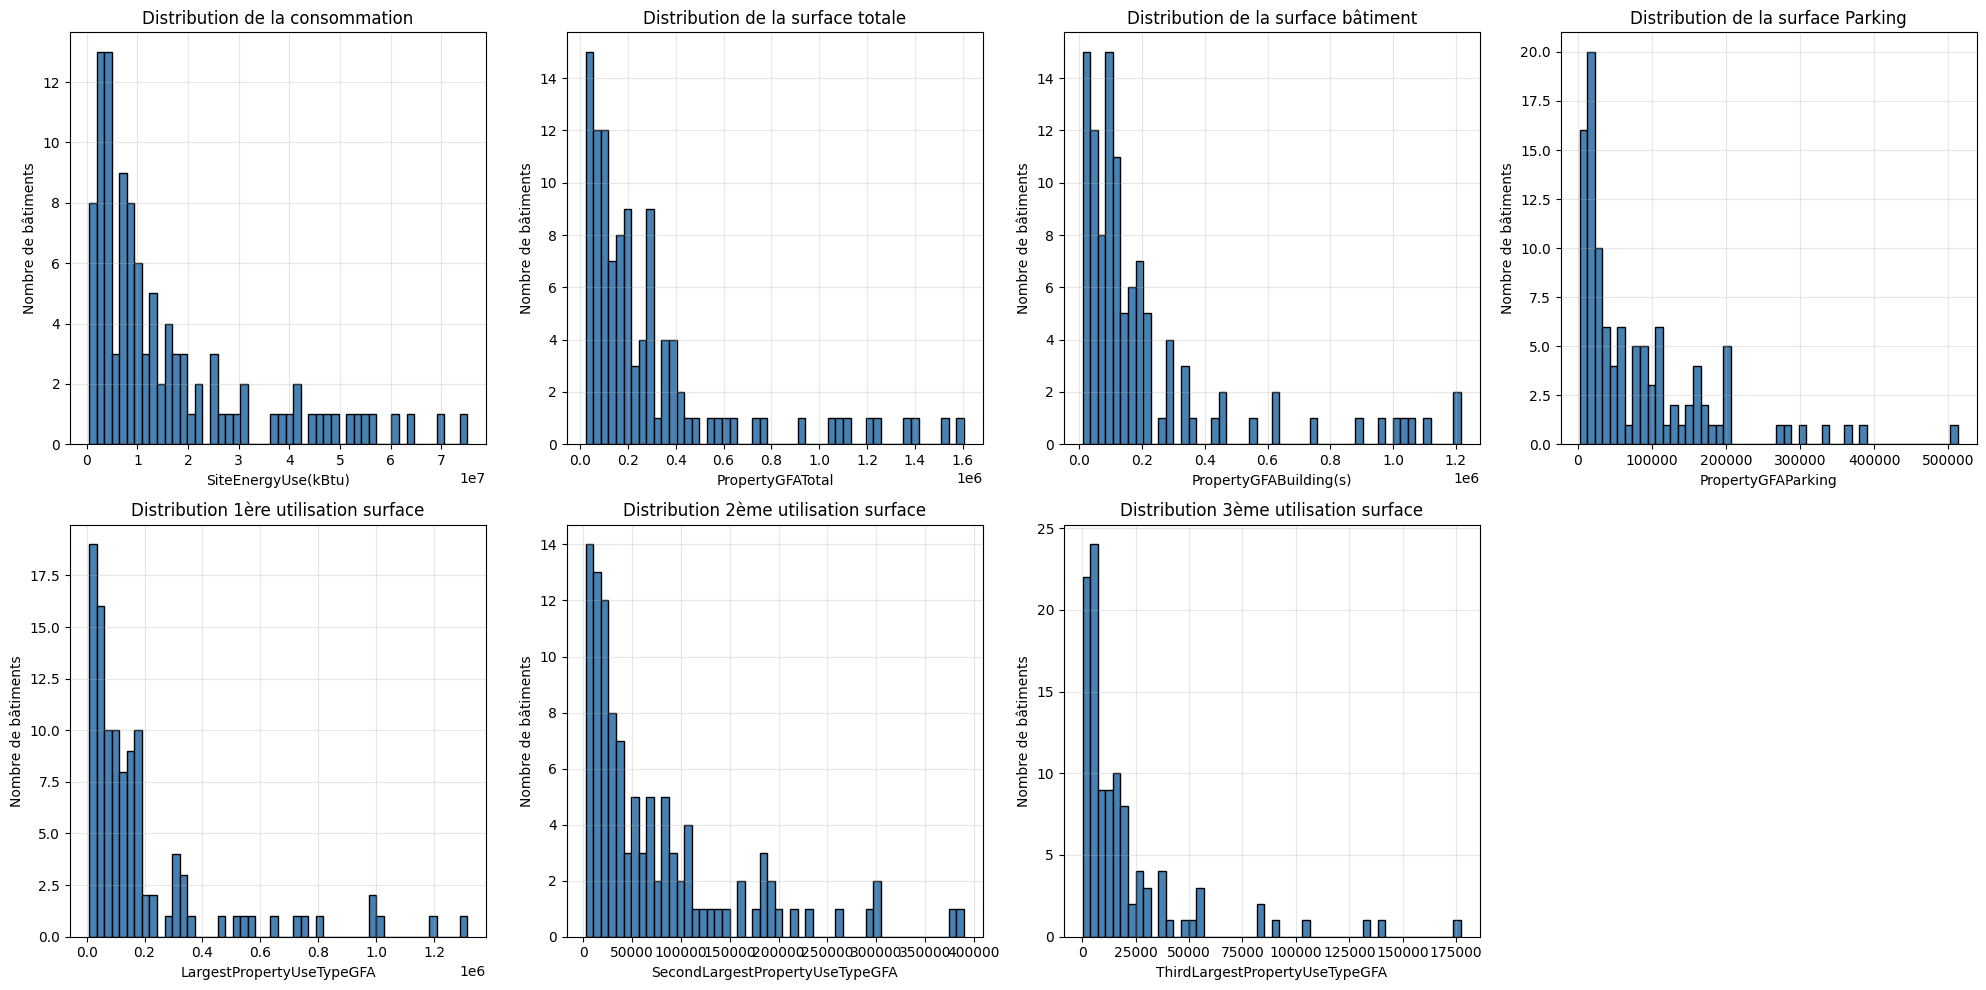

Nombre de lignes avant filtrage : 1522
Nombre de lignes après filtrage (> 0) : 108
Lignes supprimées : 1414


In [53]:
# Configuration des variables à visualiser
variables_config = {
    'SiteEnergyUse(kBtu)': 'Distribution de la consommation',
    'PropertyGFATotal': 'Distribution de la surface totale',
    'PropertyGFABuilding(s)': 'Distribution de la surface bâtiment',
    'PropertyGFAParking': 'Distribution de la surface Parking',
    'LargestPropertyUseTypeGFA': 'Distribution 1ère utilisation surface',
    'SecondLargestPropertyUseTypeGFA': 'Distribution 2ème utilisation surface',
    'ThirdLargestPropertyUseTypeGFA': 'Distribution 3ème utilisation surface'
}

# Filtrage des valeurs nulles (boucle pour construire le filtre)
mask = True  # Initialisation
for col in variables_config.keys():
    mask &= (df_clean[col] > 0)

df_no_zero = df_clean[mask]

# Création des graphiques
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()  # Transformation en tableau 1D pour faciliter l'itération

for idx, (col_name, title) in enumerate(variables_config.items()):
    axes[idx].hist(df_no_zero[col_name], bins=50, color='steelblue', edgecolor='black')
    axes[idx].set_xlabel(col_name)
    axes[idx].set_ylabel('Nombre de bâtiments')
    axes[idx].set_title(title)
    axes[idx].grid(True, alpha=0.3)

# Masquer le dernier subplot (8ème position inutilisée)
axes[7].axis('off')

plt.tight_layout()
plt.show()

print(f"Nombre de lignes avant filtrage : {len(df_clean)}")
print(f"Nombre de lignes après filtrage (> 0) : {len(df_no_zero)}")
print(f"Lignes supprimées : {len(df_clean) - len(df_no_zero)}")

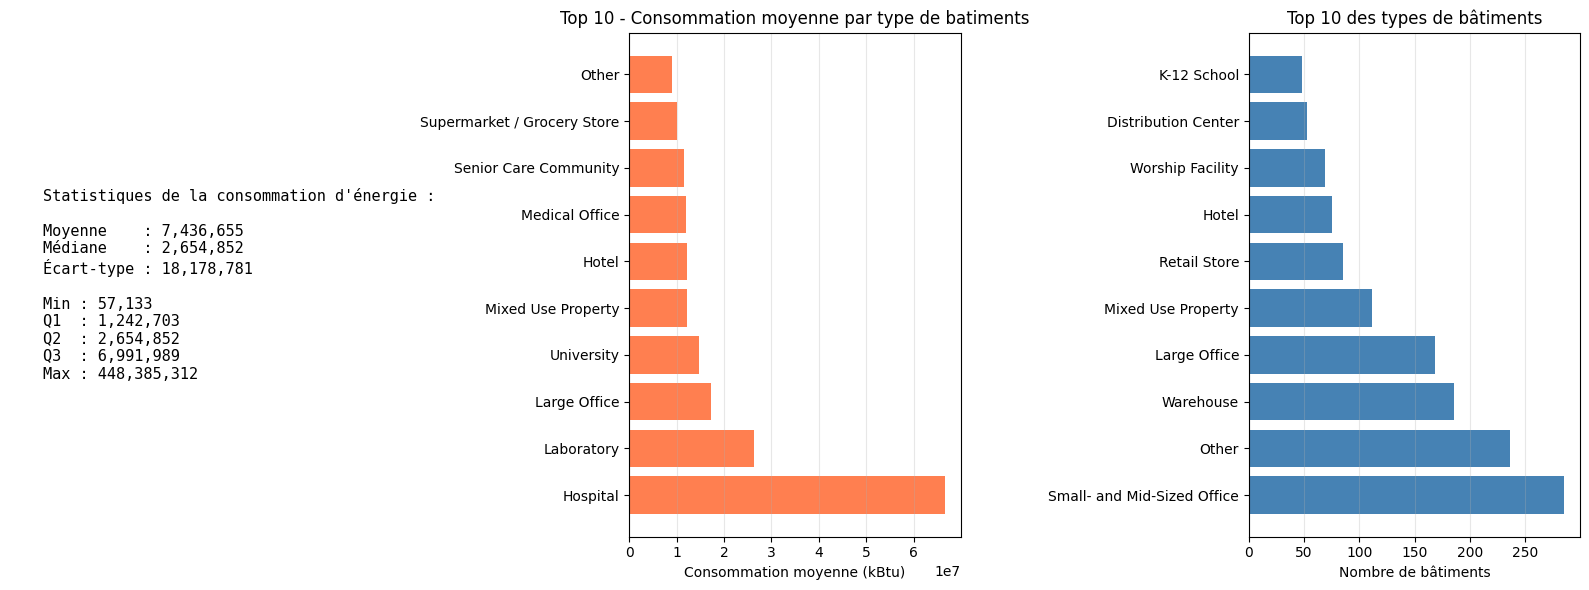

In [17]:
# Graphique 3 : Statistiques
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
stats_text = f"""
Statistiques de la consommation d'énergie :

Moyenne    : {df_clean['SiteEnergyUse(kBtu)'].mean():,.0f}
Médiane    : {df_clean['SiteEnergyUse(kBtu)'].median():,.0f}
Écart-type : {df_clean['SiteEnergyUse(kBtu)'].std():,.0f}

Min : {df_clean['SiteEnergyUse(kBtu)'].min():,.0f}
Q1  : {df_clean['SiteEnergyUse(kBtu)'].quantile(0.25):,.0f}
Q2  : {df_clean['SiteEnergyUse(kBtu)'].quantile(0.50):,.0f}
Q3  : {df_clean['SiteEnergyUse(kBtu)'].quantile(0.75):,.0f}
Max : {df_clean['SiteEnergyUse(kBtu)'].max():,.0f}
"""
axes[0].text(0.1, 0.5, stats_text, fontsize=11, family='monospace', verticalalignment='center')
axes[0].axis('off')

# Graphique 2 : Consommation moyenne par type
mean_consumption = df_clean.groupby('PrimaryPropertyType')['SiteEnergyUse(kBtu)'].mean().sort_values(ascending=False).head(10)
axes[1].barh(range(len(mean_consumption)), mean_consumption.values, color='coral')
axes[1].set_yticks(range(len(mean_consumption)))
axes[1].set_yticklabels(mean_consumption.index)
axes[1].set_xlabel('Consommation moyenne (kBtu)')
axes[1].set_title('Top 10 - Consommation moyenne par type de batiments')
axes[1].grid(axis='x', alpha=0.3)

# Graphique 1 : Nombre de bâtiments par type
type_counts = df_clean['PrimaryPropertyType'].value_counts().head(10)
axes[2].barh(range(len(type_counts)), type_counts.values, color='steelblue')
axes[2].set_yticks(range(len(type_counts)))
axes[2].set_yticklabels(type_counts.index)
axes[2].set_xlabel('Nombre de bâtiments')
axes[2].set_title('Top 10 des types de bâtiments')
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

**Analyse**  

**Consommation d'énergie par rapport au nombre de batiments.**  
Pour une meilleur visualisation, un histogramme en echelle log a été fait, et les batiments de production 0 (il y en a 16) ont été exclus.  
-> **la consommation d'energie n'est pas lié au nombre de batiments** car l'histograme s'écrase. 

**Graphique Top 10 des types de batiments.**  
Bâtiments les plus nombreux sont Small and Mid Sized OPffice / petit et moyen bureau, Other / autres, WareHouse/ entrepot.

**Graphique Top 10 - Consommation moyenne par type de batiments**  
grand consommateur d'energie (consommation doublé) : Hospital -> les hopitaux, puis Laboratory -> les laboratoires, Large Office -> Bureaux et de façon à peu près similaire : University -> Université, Mixed Use Property -> Propriété mixes, Hotel.  
Cela confirme que **La consommation d'energie n'est pas lié au nombre de batiment**

#### b) Partie 2 : Analyse approfondie Surface vs Consommationde la variable cible : SiteEnergyUse(kBtu)
  - Analyse avec la **date de construction** des batiments
  - Analyse avec la **surface** des batiments

### E/ Évaluation de deux approches : IQR et Z-SCORE de la Target *SiteEnergyUse*

In [18]:
# ===== MÉTHODE 1 : IQR =====
print("\n1️⃣ MÉTHODE IQR (Interquartile Range)")
print("-"*80)

Q1 = df_clean['SiteEnergyUse(kBtu)'].quantile(0.25)
Q3 = df_clean['SiteEnergyUse(kBtu)'].quantile(0.75)
IQR = Q3 - Q1
limite_basse_iqr = Q1 - 1.5 * IQR
limite_haute_iqr = Q3 + 1.5 * IQR

outliers_iqr = df_clean[(df_clean['SiteEnergyUse(kBtu)'] < limite_basse_iqr) | 
                         (df_clean['SiteEnergyUse(kBtu)'] > limite_haute_iqr)]

print(f"   Limite basse : {limite_basse_iqr:,.0f}")
print(f"   Limite haute : {limite_haute_iqr:,.0f}")
print(f"   IQR : {IQR:,.0f}")
print(f"   Nombre d'outliers détectés : {len(outliers_iqr)} ({len(outliers_iqr)/len(df_clean)*100:.1f}%)")

# ===== MÉTHODE 2 : Z-SCORE =====
print("\n2️⃣ MÉTHODE Z-SCORE (écart à la moyenne)")
print("-"*80)

mean = df_clean['SiteEnergyUse(kBtu)'].mean()
std = df_clean['SiteEnergyUse(kBtu)'].std()

# Calculer le z-score pour chaque valeur
df_clean['z_score'] = np.abs((df_clean['SiteEnergyUse(kBtu)'] - mean) / std)

# Seuil classique : |z| > 3
outliers_zscore = df_clean[df_clean['z_score'] > 3]

print(f"   Moyenne : {mean:,.0f}")
print(f"   Écart-type : {std:,.0f}")
print(f"   Seuil utilisé : |z-score| > 3")
print(f"   Nombre d'outliers détectés : {len(outliers_zscore)} ({len(outliers_zscore)/len(df_clean)*100:.1f}%)")

# ===== COMPARAISON =====
print("\n📊 COMPARAISON")
print("-"*80)
print(f"   IQR détecte : {len(outliers_iqr)} outliers")
print(f"   Z-score détecte : {len(outliers_zscore)} outliers")

# Combien sont communs aux deux méthodes ?
communs = set(outliers_iqr.index).intersection(set(outliers_zscore.index))
print(f"   Outliers communs aux deux méthodes : {len(communs)}")

print("\n" + "="*80)

# Nettoyer la colonne temporaire
df_clean = df_clean.drop(columns=['z_score'])


1️⃣ MÉTHODE IQR (Interquartile Range)
--------------------------------------------------------------------------------
   Limite basse : -7,381,228
   Limite haute : 15,615,920
   IQR : 5,749,287
   Nombre d'outliers détectés : 169 (11.1%)

2️⃣ MÉTHODE Z-SCORE (écart à la moyenne)
--------------------------------------------------------------------------------
   Moyenne : 7,436,655
   Écart-type : 18,178,781
   Seuil utilisé : |z-score| > 3
   Nombre d'outliers détectés : 16 (1.1%)

📊 COMPARAISON
--------------------------------------------------------------------------------
   IQR détecte : 169 outliers
   Z-score détecte : 16 outliers
   Outliers communs aux deux méthodes : 16



***Analyse***  

Selon le calcul des deux métriques Outlier.   
Nous avons une différence de 156 Outliers (IQR 174 contre Z-score 18).   
Le calcul de **Z-score** est basé sur la moyenne des variables, il prend donc on compte tous les Outliers (dont les valeurs les + extreme) ce qui biaise la 'normalité' du score..  

**IQR*** prend une dispersion entre 25% et 75% des valeurs. Cela donne une vision 'nomale' des données. 

On voit que la dispersion des valeurs Ecart-type et IQR sont très différentes dans leur valeurs **Écart-type : 17 654 702** et **IQR : 5,538,065**

*Pour une étude plus rigoureuse, je prend comme reference d'Outlier IQR.*

📊 VISUALISATION DE LA VARIABLE CIBLE : SiteEnergyUse(kBtu)
--------------------------------------------------------------------------------


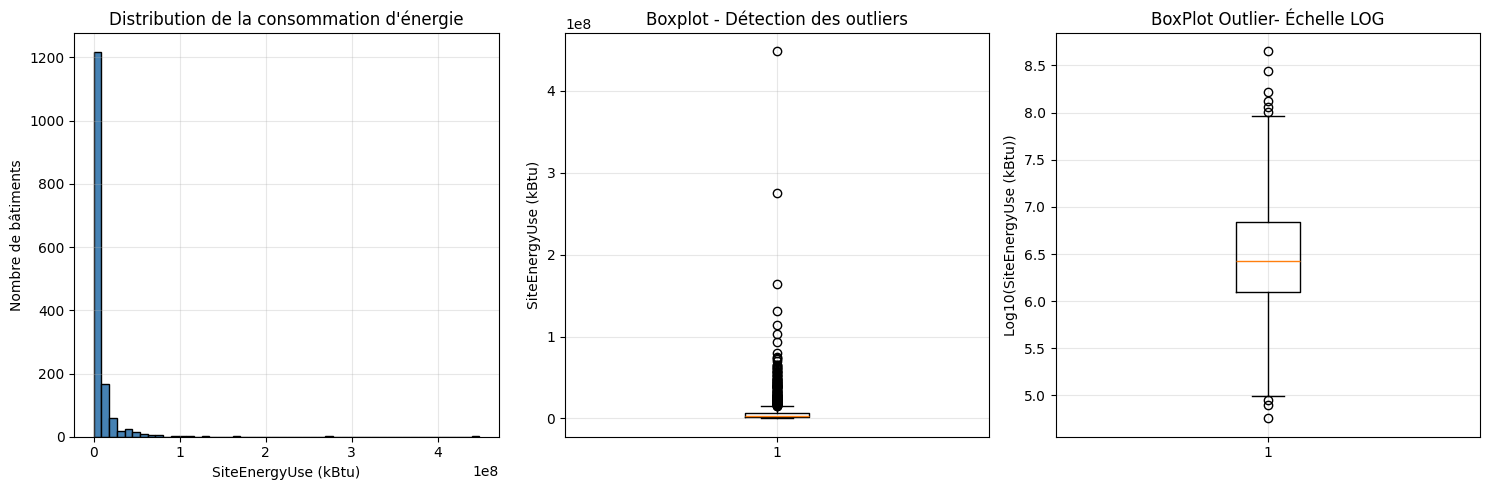

In [19]:
print("📊 VISUALISATION DE LA VARIABLE CIBLE : SiteEnergyUse(kBtu)")
print("-"*80)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# histogramme
axes[0].hist(df_clean['SiteEnergyUse(kBtu)'].dropna(), bins=50, color='steelblue', edgecolor='black')
axes[0].set_xlabel('SiteEnergyUse (kBtu)')
axes[0].set_ylabel('Nombre de bâtiments')
axes[0].set_title('Distribution de la consommation d\'énergie')
axes[0].grid(True, alpha=0.3)

# Boxplot - Outliers
axes[1].boxplot(df_clean['SiteEnergyUse(kBtu)'].dropna())
axes[1].set_ylabel('SiteEnergyUse (kBtu)')
axes[1].set_title('Boxplot - Détection des outliers')
axes[1].grid(True, alpha=0.3)

# Boxplot - Outlier Distribution LOG 
axes[2].boxplot(np.log10(df_clean['SiteEnergyUse(kBtu)'].dropna() + 1))
axes[2].set_ylabel('Log10(SiteEnergyUse (kBtu))')
axes[2].set_title('BoxPlot Outlier- Échelle LOG')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


On analyse quel type de batiments constituent les Outliers, et voir s'il y a des incohérences entre les  batiments et la production excessive.

Ainsi on  va comparer *SiteEnergyUse* avec :
- le type de batiments
- la surface des batiments

### F/ Observation des Outliers de la target

In [20]:
Q1 = df_clean['SiteEnergyUse(kBtu)'].quantile(0.25)
Q3 = df_clean['SiteEnergyUse(kBtu)'].quantile(0.75)
IQR = Q3 - Q1
limite_basse = Q1 - 1.5 * IQR
limite_haute = Q3 + 1.5 * IQR
outliers = df_clean[df_clean['SiteEnergyUse(kBtu)'] > limite_haute]

print(f"\n📊 Types de bâtiments parmi les outliers :")
print(outliers['PrimaryPropertyType'].value_counts())

print(f"\n📊 Description de la surface des bâtiments parmi les outliers :")
print(outliers['PropertyGFATotal'].describe())

print(f"\n📊 Top 5 des plus gros consommateurs parmi les outliers:")
top5 = outliers.nlargest(5, 'SiteEnergyUse(kBtu)')[['BuildingType','PrimaryPropertyType','PropertyGFATotal','SiteEnergyUse(kBtu)']]
print(top5)

print("\n" + "="*80)


📊 Types de bâtiments parmi les outliers :
PrimaryPropertyType
Large Office                   66
Other                          29
Mixed Use Property             16
Hotel                          15
Medical Office                 12
Retail Store                    6
Laboratory                      6
Senior Care Community           5
University                      4
Hospital                        3
Small- and Mid-Sized Office     2
Warehouse                       1
Distribution Center             1
Refrigerated Warehouse          1
Supermarket / Grocery Store     1
Residence Hall                  1
Name: count, dtype: int64

📊 Description de la surface des bâtiments parmi les outliers :
count    1.690000e+02
mean     4.566321e+05
std      3.886293e+05
min      3.397100e+04
25%      1.900000e+05
50%      3.363300e+05
75%      5.403600e+05
max      2.200000e+06
Name: PropertyGFATotal, dtype: float64

📊 Top 5 des plus gros consommateurs parmi les outliers:
        BuildingType PrimaryPro

**Analyse**  
Les Outliers de la Target sont légitimes.  
On peut se poser la question si **Mixed Use Property, Other, Hospital, University** peuvent être considéré comme des lieux d'habitation ?

Ces bâtiments consomment beaucoup d'énergie :
- Universités éclairage, materiel informatique.
- Hôpitaux 24h/24 avec équipements médicaux
- Bâtiment à usage mixed
- Autres

On regarde plus en détails ce que contient les 29 **Other**

#### a) Analyse des individus "Other" dans Outlier de la target

In [21]:
Q1 = df_clean['SiteEnergyUse(kBtu)'].quantile(0.25)
Q3 = df_clean['SiteEnergyUse(kBtu)'].quantile(0.75)
IQR = Q3 - Q1
limite_haute = Q3 + 1.5 * IQR

outliers = df_clean[df_clean['SiteEnergyUse(kBtu)'] > limite_haute]

# Filtrer les "Other" dans 'PrimaryPropertyType'/ il y en a 29
other_outliers = outliers[outliers['PrimaryPropertyType'] == 'Other']

# Usage principal réel
print("\n 1/ Usage principal (LargestPropertyUseType) :")
print(other_outliers['LargestPropertyUseType'].value_counts())

# Top 5 les + energivores
print("--------"*10)
print("\n 3/ Top 10 les plus énergivores :")
display(other_outliers.nlargest(10, 'SiteEnergyUse(kBtu)')[
    ['BuildingType','ListOfAllPropertyUseTypes','LargestPropertyUseType', 'PropertyGFABuilding(s)', 'SiteEnergyUse(kBtu)','NumberofBuildings' ]
])

print("--------"*10)


 1/ Usage principal (LargestPropertyUseType) :
LargestPropertyUseType
Other                                    13
Other - Entertainment/Public Assembly     3
Data Center                               3
Urgent Care/Clinic/Other Outpatient       2
Other - Recreation                        2
Library                                   1
Courthouse                                1
Parking                                   1
Strip Mall                                1
Other - Mall                              1
Lifestyle Center                          1
Name: count, dtype: int64
--------------------------------------------------------------------------------

 3/ Top 10 les plus énergivores :


,BuildingType,ListOfAllPropertyUseTypes,LargestPropertyUseType,PropertyGFABuilding(s),SiteEnergyUse(kBtu),NumberofBuildings
558,NonResidential,"Data Center, Office",Data Center,429405,274682208.0,1.0
340,Campus,"Other, Parking",Other,535947,131373880.0,1.0
119,NonResidential,Other,Other,230638,65336980.0,1.0
187,NonResidential,Other,Other,230880,62197176.0,1.0
329,NonResidential,Urgent Care/Clinic/Other Outpatient,Urgent Care/Clinic/Other Outpatient,158738,61762380.0,1.0
155,NonResidential,"Other - Entertainment/Public Assembly, Parking",Other - Entertainment/Public Assembly,1258280,59757440.0,1.0
158,NonResidential,Other - Entertainment/Public Assembly,Other - Entertainment/Public Assembly,1172127,58761304.0,1.0
21,NonResidential,Other,Other,385274,47859812.0,1.0
564,NonResidential,"Office, Other - Entertainment/Public Assembly,...",Other - Mall,947987,46510960.0,1.0
20,NonResidential,Courthouse,Courthouse,540360,44984468.0,1.0


--------------------------------------------------------------------------------


**ANALYSE**  
On remarque deux individus très énergivores : 
- 1 Data Center, sa consommation par rapport à la superficie et son nombre de batiment est extreme. 
- 1 campus/Parking, sa consommation d'energie par rapport à sa superficie et nombre de batiment est cohérent.

In [22]:
print(f"Le nouveau dataset est composé de {df_clean.shape[0]} lignes et de {df_clean.shape[1]} colonnes" )

Le nouveau dataset est composé de 1522 lignes et de 35 colonnes


**Maintenant, que mon dataset possède des valeurs exploitable, je vais regarder mes features incomplètes**

## 5 / Visualisation des features incomplètes

/tmp/ipykernel_33616/1784392954.py:30: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/veron/miniconda3/envs/seattle/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


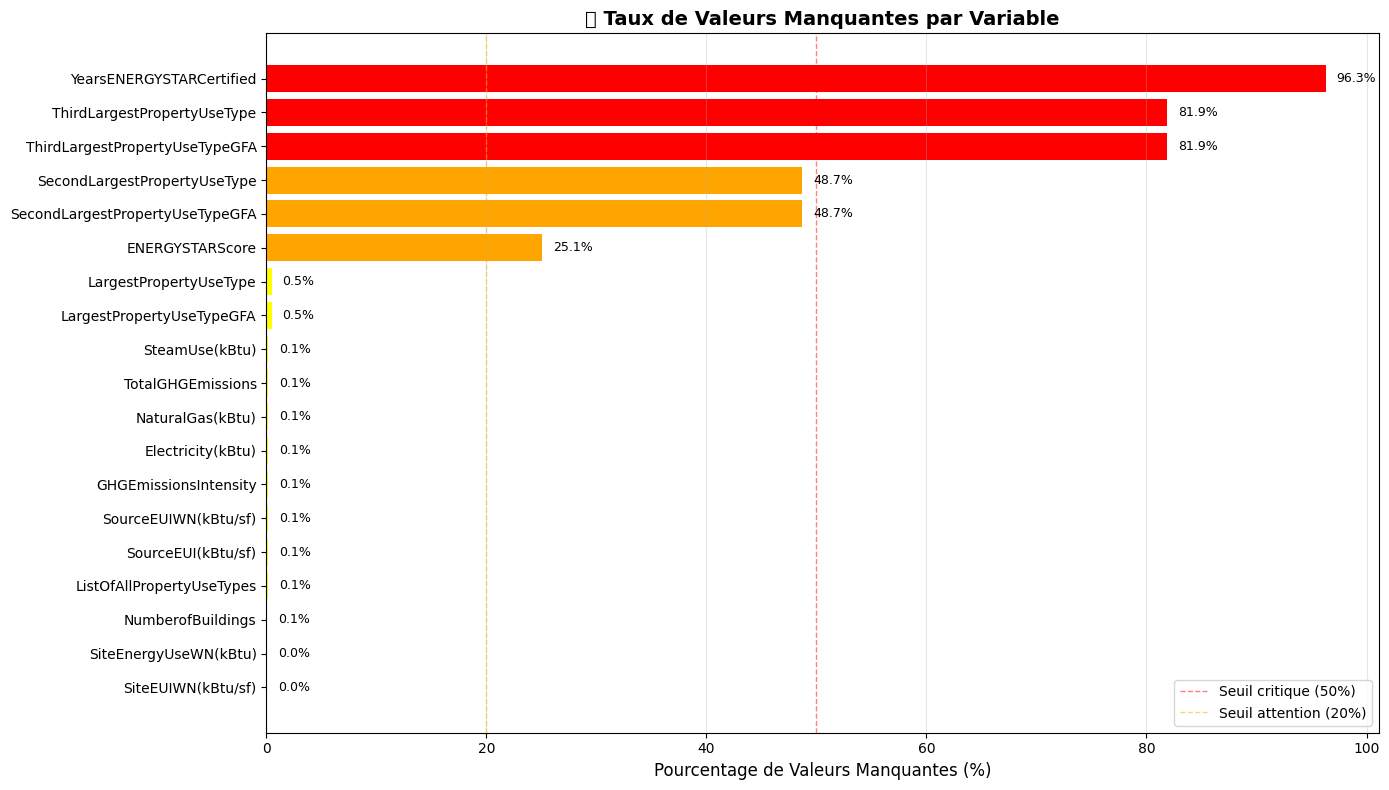

In [23]:
missing = pd.DataFrame({
    'Colonne': df.columns,
    'NaN_Count': df.isnull().sum(),
    'NaN_Percent': (df.isnull().sum() / len(df) * 100).round(2),
    'Type': df.dtypes
})

missing = missing[missing['NaN_Count'] > 0].sort_values('NaN_Percent', ascending=False)
fig, ax = plt.subplots(figsize=(14, 8))

if len(missing) > 0:
    missing_sorted = missing.sort_values('NaN_Percent', ascending=True)
    colors = ['red' if x > 50 else 'orange' if x > 20 else 'yellow' 
              for x in missing_sorted['NaN_Percent']]
    
    bars = ax.barh(missing_sorted['Colonne'], missing_sorted['NaN_Percent'], color=colors)
    ax.set_xlabel('Pourcentage de Valeurs Manquantes (%)', fontsize=12)
    ax.set_title('📊 Taux de Valeurs Manquantes par Variable', fontsize=14, fontweight='bold')
    ax.axvline(x=50, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Seuil critique (50%)')
    ax.axvline(x=20, color='orange', linestyle='--', linewidth=1, alpha=0.5, label='Seuil attention (20%)')
    ax.legend()
    ax.grid(axis='x', alpha=0.3)
    
    # Ajouter les valeurs sur les barres
    for i, bar in enumerate(bars):
        width = bar.get_width()
        ax.text(width + 1, bar.get_y() + bar.get_height()/2, 
                f'{width:.1f}%', ha='left', va='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()
else:
    print("✅ Aucune valeur manquante dans le dataset !")

**Analyse par catégories des valeurs manquantes**
- YearsENERGYSTARCertified (94%)
- ThirdLargestPropertyUseType (78%)
- ThirdLargestPropertyUseTypeGFA (78%)
- SecondLargestPropertyUseType (48%)
- SecondLargestPropertyUseTypeGFA (48%)
- ENERGYSTARScore (34%)

In [24]:
df_clean = df_clean.drop(columns=['YearsENERGYSTARCertified'])
print(df_clean.info())

<class 'pandas.core.frame.DataFrame'>
Index: 1522 entries, 0 to 3375
Data columns (total 34 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   DataYear                         1522 non-null   int64  
 1   BuildingType                     1522 non-null   object 
 2   PrimaryPropertyType              1522 non-null   object 
 3   CouncilDistrictCode              1522 non-null   int64  
 4   Neighborhood                     1522 non-null   object 
 5   Latitude                         1522 non-null   float64
 6   Longitude                        1522 non-null   float64
 7   YearBuilt                        1522 non-null   int64  
 8   NumberofBuildings                1522 non-null   float64
 9   NumberofFloors                   1522 non-null   int64  
 10  PropertyGFATotal                 1522 non-null   int64  
 11  PropertyGFAParking               1522 non-null   int64  
 12  PropertyGFABuilding(s)   


4️⃣ Année de construction vs Consommation
--------------------------------------------------------------------------------


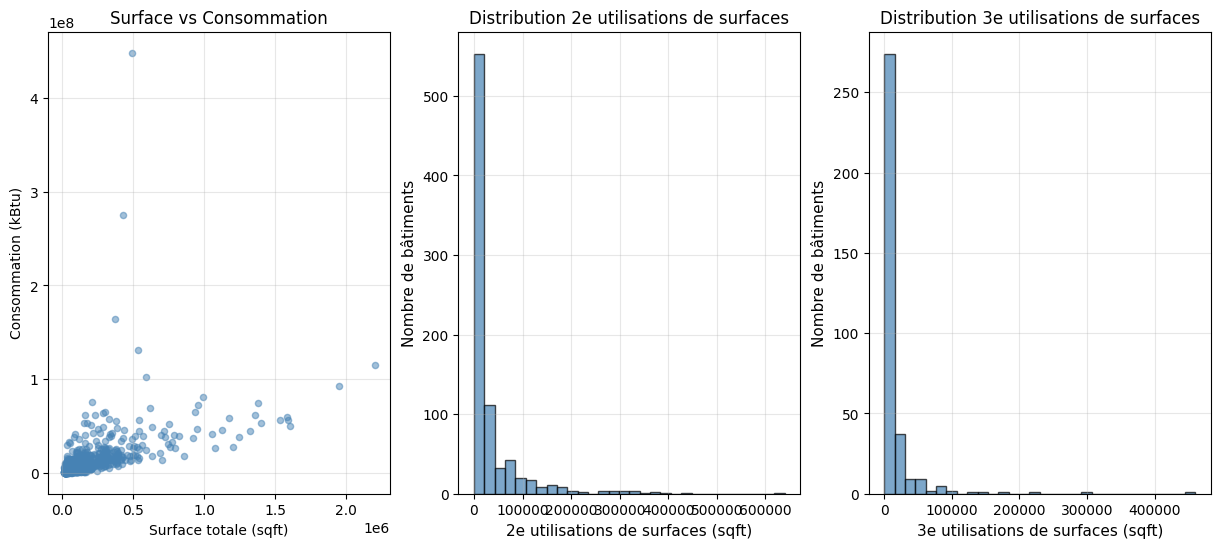

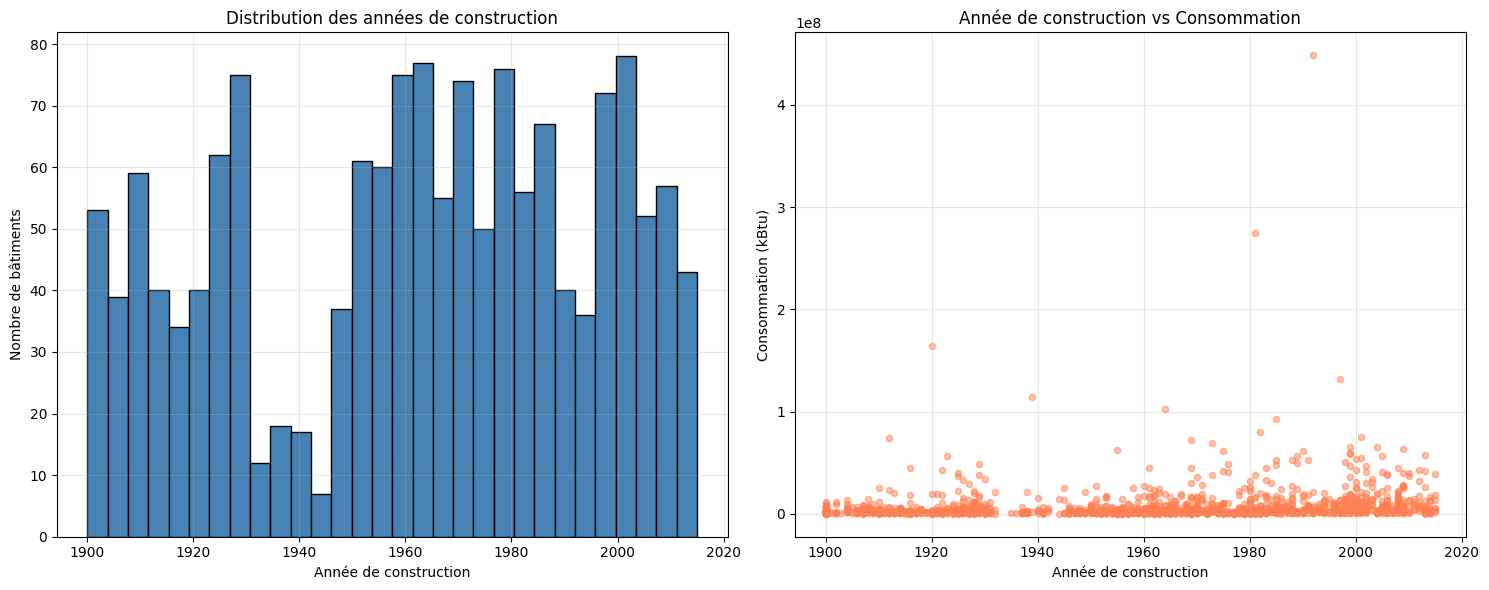

   Corrélation Année/Consommation : 0.149
   Corrélation Surface Totale/Consommation : 0.553


In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

# Graphique 1 : Scatter plot
axes[0].scatter(df_clean['PropertyGFATotal'], 
                df_clean['SiteEnergyUse(kBtu)'], 
                alpha=0.5, s=20, color='steelblue')
axes[0].set_xlabel('Surface totale (sqft)')
axes[0].set_ylabel('Consommation (kBtu)')
axes[0].set_title('Surface vs Consommation')
axes[0].grid(True, alpha=0.3)

axes[1].hist(df_clean['SecondLargestPropertyUseTypeGFA'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('2e utilisations de surfaces (sqft)', fontsize=11)
axes[1].set_ylabel('Nombre de bâtiments', fontsize=11)
axes[1].set_title('Distribution 2e utilisations de surfaces', fontsize=12)
axes[1].grid(True, alpha=0.3)

axes[2].hist(df_clean['ThirdLargestPropertyUseTypeGFA'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[2].set_xlabel('3e utilisations de surfaces (sqft)', fontsize=11)
axes[2].set_ylabel('Nombre de bâtiments', fontsize=11)
axes[2].set_title('Distribution 3e utilisations de surfaces', fontsize=12)
axes[2].grid(True, alpha=0.3)



# ============================================================================
# 4. ANNÉE DE CONSTRUCTION vs Consommation
# ============================================================================
print("\n4️⃣ Année de construction vs Consommation")
print("-"*80)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Graphique 1 : Distribution des années
axes[0].hist(df_clean['YearBuilt'], bins=30, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Année de construction')
axes[0].set_ylabel('Nombre de bâtiments')
axes[0].set_title('Distribution des années de construction')
axes[0].grid(True, alpha=0.3)

# Graphique 2 : Année vs Consommation
axes[1].scatter(df_clean['YearBuilt'], 
                df_clean['SiteEnergyUse(kBtu)'], 
                alpha=0.5, s=20, color='coral')
axes[1].set_xlabel('Année de construction')
axes[1].set_ylabel('Consommation (kBtu)')
axes[1].set_title('Année de construction vs Consommation')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculer la corrélation
correlation = df_clean['PropertyGFATotal'].corr(df_clean['SiteEnergyUse(kBtu)'])
correlation_year = df_clean['YearBuilt'].corr(df_clean['SiteEnergyUse(kBtu)'])

print(f"   Corrélation Année/Consommation : {correlation_year:.3f}")
print(f"   Corrélation Surface Totale/Consommation : {correlation:.3f}")

## Conclusion : Enregistrement du nouveau Dataset

In [26]:
print(df_clean.info())

<class 'pandas.core.frame.DataFrame'>
Index: 1522 entries, 0 to 3375
Data columns (total 34 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   DataYear                         1522 non-null   int64  
 1   BuildingType                     1522 non-null   object 
 2   PrimaryPropertyType              1522 non-null   object 
 3   CouncilDistrictCode              1522 non-null   int64  
 4   Neighborhood                     1522 non-null   object 
 5   Latitude                         1522 non-null   float64
 6   Longitude                        1522 non-null   float64
 7   YearBuilt                        1522 non-null   int64  
 8   NumberofBuildings                1522 non-null   float64
 9   NumberofFloors                   1522 non-null   int64  
 10  PropertyGFATotal                 1522 non-null   int64  
 11  PropertyGFAParking               1522 non-null   int64  
 12  PropertyGFABuilding(s)   

In [27]:
df_clean.to_pickle('df_clean.pkl')
print("✅ Fichier sauvegardé en pickle")
print(f"\n📊 RÉCAPITULATIF :")
print(f"  Dataset initial : {len(df):,} lignes × {len(df.columns)} colonnes")
print(f"  Dataset final : {len(df_clean):,} lignes × {len(df_clean.columns)} colonnes")
print(f"  NaN restants : {df_clean.isnull().sum().sum()}")

✅ Fichier sauvegardé en pickle

📊 RÉCAPITULATIF :
  Dataset initial : 3,170 lignes × 35 colonnes
  Dataset final : 1,522 lignes × 34 colonnes
  NaN restants : 4281


**Analyse**  

1/ Analyse des Variables

- Variable TotalGHGEmissions : 
    - La valeur minimale est de  -0.800000, on ne peut pas avoir une émission de CO2 négative -> nous avons une valeur aberrante. 
    - La médiane est de 49.44 (2nd quartile) et l a valeur max est de 16 870 -> cette amplitude nous suggère un outlier.  


- Variable SiteEnergyUse(kBtu):
    - Valeur min: 0 kBtu. Certains batiments ne consomment pas d'énergie, cela concerne 16 bâtiments.
    - Valeur max : 4.48x10⁸ est bien supérieur à la médiane (7.13x10⁶)-> variable qui a des extremes. minimum et maximum, mais nous avons vu dans le traitement des Outliers qu'il y a des consommations différentes selon le type et la surface des batiments.

**Pour Target je vais prendre SiteEnergyUse(kBtu)**

2/ Etudes des corrélations

Il y a une corrélation entre la surface et la consommation.  
Il n'y a pas très peu de corrélation entre l'année de constructions et la consommations.  
Il n'y a pas de corrélation entre la consommation d'energie et le nombre de batiments.  


3/ Consommation moyenne par type de batiments
grand consommateur d'energie (consommation doublé) :
   - 1/ Hospital -> les hopitaux
 
puis
 - 2/ Laboratory -> les laboratoires

puis 
 - 3/ Large Office -> Bureaux
 
et de façon à peu près similaire :
 - 4/ University -> Université
 - 5/ Mixed Use Property -> Propriété mixes
 - 6/ Hotel
 
**Étape suivante**

La suite de l’analyse portera sur la détection du data leakage, à travers :

l’étude des corrélations entre variables à l’aide d’une matrice de corrélation ;

la mise en place et la comparaison de plusieurs modèles :

- modèle dummy (baseline),

- régression linéaire,

- Random Forest,

- SVR.
